# Notebook 2 — Model Comparison

**Project:** AirSense — Indoor Air Quality Monitoring & ML  
**Author:** AirSense ML Team  
**Date:** 2026-05-18

---

This notebook is the **main ML deliverable**. It trains and compares all models for two tasks:
- **Task A — Regression:** Predict AQI (continuous) from sensor readings
- **Task B — Classification:** Predict AQI category (6 classes) from sensor readings

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

from src.data.loader import load_primary
from src.data.preprocessor import (
    clean, add_aqi, add_time_features, add_lag_features,
    add_rolling_features, encode_labels, split, scale_features
)
from src.evaluation.metrics import regression_metrics, classification_metrics
from src.evaluation.reporter import build_regression_df, build_classification_df, save_report

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('Setup complete. Libraries loaded.')

Setup complete. Libraries loaded.


## Introduction

### Task A: Regression — Predict AQI

The **AQI** (Air Quality Index) is a continuous value in [0, 500] computed from PM₂.₅ and PM₁₀ via the EPA piecewise-linear formula. Regression models predict this value directly.

### Task B: Classification — Predict AQI Category

The **AQI Category** is one of 6 ordinal classes derived from the AQI value:

| Index | Label | AQI Range |
|-------|-------|-----------|
| 0 | Good | 0–50 |
| 1 | Moderate | 51–100 |
| 2 | Unhealthy for Sensitive Groups | 101–150 |
| 3 | Unhealthy | 151–200 |
| 4 | Very Unhealthy | 201–300 |
| 5 | Hazardous | 301–500 |

---

### Regression Metrics

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$RMSE = \sqrt{MSE}$$

$$R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

$$MAPE = \frac{100}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{\max(|y_i|, \epsilon)}$$

### Classification Metrics

$$Accuracy = \frac{TP + TN}{N}$$

$$Precision = \frac{TP}{TP + FP} \quad \text{(macro-averaged)}$$

$$Recall = \frac{TP}{TP + FN} \quad \text{(macro-averaged)}$$

$$F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$$

$$ROC\text{-}AUC = \text{Area under ROC curve (One-vs-Rest)}$$

In [2]:
# ── Load and re-run the full pipeline ────────────────────────────────────────
try:
    df_raw = load_primary('../data/raw/Air-Quality-Dataset.csv')
    print(f'Raw data loaded: {len(df_raw):,} rows')
except FileNotFoundError as e:
    print(f'ERROR: {e}')
    raise

# Pipeline
df = clean(df_raw)
df = add_aqi(df)
df = add_time_features(df)
df = add_lag_features(df)
df = add_rolling_features(df)
df, encoders = encode_labels(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'After preprocessing: {len(df):,} rows x {df.shape[1]} columns')

Raw data loaded: 6,200 rows
After preprocessing: 6,176 rows x 82 columns


In [3]:
# ── Feature matrix definition ────────────────────────────────────────────────
SENSOR_COLS = ['CO2', 'PM25', 'PM10', 'TEMPERATURE', 'HUMIDITY']
TIME_FEATS  = ['hour', 'day_of_week', 'month', 'is_weekend',
               'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

# Identify lag and rolling columns that were created
LAG_COLS     = [c for c in df.columns if '_lag' in c]
ROLLING_COLS = [c for c in df.columns if '_roll' in c]

FEATURE_COLS = SENSOR_COLS + TIME_FEATS + LAG_COLS + ROLLING_COLS
# Keep only columns that actually exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

REG_TARGET = 'AQI'
CLF_TARGET = 'AQI_IDX'

print(f'Feature columns: {len(FEATURE_COLS)}')
print(f'Regression target : {REG_TARGET}')
print(f'Classification target: {CLF_TARGET}')
print(f'Classes (AQI_IDX) : {sorted(df[CLF_TARGET].unique())}')

Feature columns: 68
Regression target : AQI
Classification target: AQI_IDX
Classes (AQI_IDX) : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [4]:
# ── Train / Val / Test split ─────────────────────────────────────────────────
train, val, test = split(df, test_size=0.20, val_size=0.10)
print(f'Train: {len(train):,}  |  Val: {len(val):,}  |  Test: {len(test):,}')

# Scale features
train_s, val_s, test_s, scaler = scale_features(train, val, test, FEATURE_COLS)

X_train = train_s[FEATURE_COLS].values
X_val   = val_s[FEATURE_COLS].values
X_test  = test_s[FEATURE_COLS].values

y_train_reg = train[REG_TARGET].values
y_val_reg   = val[REG_TARGET].values
y_test_reg  = test[REG_TARGET].values

y_train_clf = train[CLF_TARGET].values.astype(int)
y_val_clf   = val[CLF_TARGET].values.astype(int)
y_test_clf  = test[CLF_TARGET].values.astype(int)

print(f'X_train shape: {X_train.shape}')
print(f'y_train_reg range: [{y_train_reg.min():.1f}, {y_train_reg.max():.1f}]')
print(f'y_train_clf unique classes: {np.unique(y_train_clf)}')

Train: 4,324  |  Val: 617  |  Test: 1,235
X_train shape: (4324, 68)
y_train_reg range: [0.0, 500.0]
y_train_clf unique classes: [0 1 2 3 4 5]


---
## TASK A: Regression — Predict AQI

We train 8 regression models:
1. Linear Regression
2. Ridge Regression (GridSearchCV over α)
3. Lasso Regression (GridSearchCV over α)
4. Polynomial Regression (degree=2)
5. Polynomial Regression (degree=3)
6. Random Forest (GridSearchCV)
7. SVR with RBF kernel (GridSearchCV)
8. XGBoost

In [5]:
from src.models.regression import (
    train_linear, train_ridge, train_lasso,
    train_polynomial, train_random_forest,
    train_svr, train_xgboost
)

reg_models = {}

print('Training Linear Regression …')
reg_models['Linear Regression'] = train_linear(X_train, y_train_reg)
print('  done.')

print('Training Ridge Regression (GridSearchCV) …')
reg_models['Ridge Regression'] = train_ridge(X_train, y_train_reg)
best_alpha = reg_models['Ridge Regression'].best_params_
print(f'  done. Best params: {best_alpha}')

print('Training Lasso Regression (GridSearchCV) …')
reg_models['Lasso Regression'] = train_lasso(X_train, y_train_reg)
best_alpha_lasso = reg_models['Lasso Regression'].best_params_
print(f'  done. Best params: {best_alpha_lasso}')

print('Training Polynomial Regression (degree=2) …')
reg_models['Polynomial (deg=2)'] = train_polynomial(X_train, y_train_reg, degree=2)
print('  done.')

print('Training Polynomial Regression (degree=3) …')
reg_models['Polynomial (deg=3)'] = train_polynomial(X_train, y_train_reg, degree=3)
print('  done.')

print('Training Random Forest Regressor (GridSearchCV) …')
reg_models['Random Forest'] = train_random_forest(X_train, y_train_reg)
best_rf = reg_models['Random Forest'].best_params_
print(f'  done. Best params: {best_rf}')

print('Training SVR (RBF kernel, GridSearchCV) …')
reg_models['SVR (RBF)'] = train_svr(X_train, y_train_reg)
best_svr = reg_models['SVR (RBF)'].best_params_
print(f'  done. Best params: {best_svr}')

print('Training XGBoost Regressor …')
reg_models['XGBoost'] = train_xgboost(X_train, y_train_reg)
print('  done.')

print(f'\nAll {len(reg_models)} regression models trained.')

Training Linear Regression …
  done.
Training Ridge Regression (GridSearchCV) …
  done. Best params: {'alpha': 100}
Training Lasso Regression (GridSearchCV) …
  done. Best params: {'alpha': 10}
Training Polynomial Regression (degree=2) …
  done.
Training Polynomial Regression (degree=3) …
  done.
Training Random Forest Regressor (GridSearchCV) …
  done. Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Training SVR (RBF kernel, GridSearchCV) …
  done. Best params: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}
Training XGBoost Regressor …
  done.

All 8 regression models trained.


### Regression Evaluation

In [6]:
reg_results = {}

for name, model in reg_models.items():
    y_pred = model.predict(X_test)
    metrics = regression_metrics(y_test_reg, y_pred)
    reg_results[name] = metrics
    print(f'{name:<30}  MAE={metrics["MAE"]:7.3f}  RMSE={metrics["RMSE"]:7.3f}  R²={metrics["R2"]:6.4f}  MAPE={metrics["MAPE"]:6.2f}%')

Linear Regression               MAE= 69.082  RMSE= 73.568  R²=-4.5990  MAPE=188.43%
Ridge Regression                MAE= 17.071  RMSE= 20.632  R²=0.5596  MAPE= 42.51%
Lasso Regression                MAE=  9.316  RMSE= 21.089  R²=0.5399  MAPE= 16.15%
Polynomial (deg=2)              MAE= 67.074  RMSE=134.533  R²=-17.7238  MAPE=166.67%
Polynomial (deg=3)              MAE=146.888  RMSE=649.362  R²=-435.2227  MAPE=321.12%
Random Forest                   MAE=  8.203  RMSE= 28.746  R²=0.1452  MAPE= 19.68%
SVR (RBF)                       MAE= 11.788  RMSE= 23.884  R²=0.4099  MAPE= 23.13%
XGBoost                         MAE=  2.161  RMSE=  9.345  R²=0.9097  MAPE=  2.75%


### Regression Results Table

In [7]:
reg_df = build_regression_df(reg_results)

def highlight_best_reg(s):
    """Highlight min RMSE/MAE green, max R² green."""
    if s.name in ('RMSE', 'MAE', 'MAPE (%)'):
        is_best = s == s.min()
    elif s.name == 'R²':
        is_best = s == s.max()
    else:
        return [''] * len(s)
    return ['background-color: #c6efce; font-weight: bold' if v else '' for v in is_best]

styled_reg = (
    reg_df.style
    .apply(highlight_best_reg)
    .set_caption('Regression Model Comparison — Test Set (sorted by RMSE)')
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R²': '{:.4f}', 'MAPE (%)': '{:.2f}'})
)
styled_reg

,Model,MAE,RMSE,R²,MAPE (%)
1,XGBoost,2.1608,9.3453,0.9097,2.75
2,Ridge Regression,17.0707,20.6324,0.5596,42.51
3,Lasso Regression,9.3165,21.0886,0.5399,16.15
4,SVR (RBF),11.7877,23.8835,0.4099,23.13
5,Random Forest,8.2027,28.7459,0.1452,19.68
6,Linear Regression,69.0821,73.5681,-4.5990,188.43
7,Polynomial (deg=2),67.0738,134.5332,-17.7238,166.67
8,Polynomial (deg=3),146.8882,649.3620,-435.2227,321.12


### Regression Visualization — Predicted vs Actual (Top 3 Models)

Top 3 regression models (by RMSE): ['XGBoost', 'Ridge Regression', 'Lasso Regression']


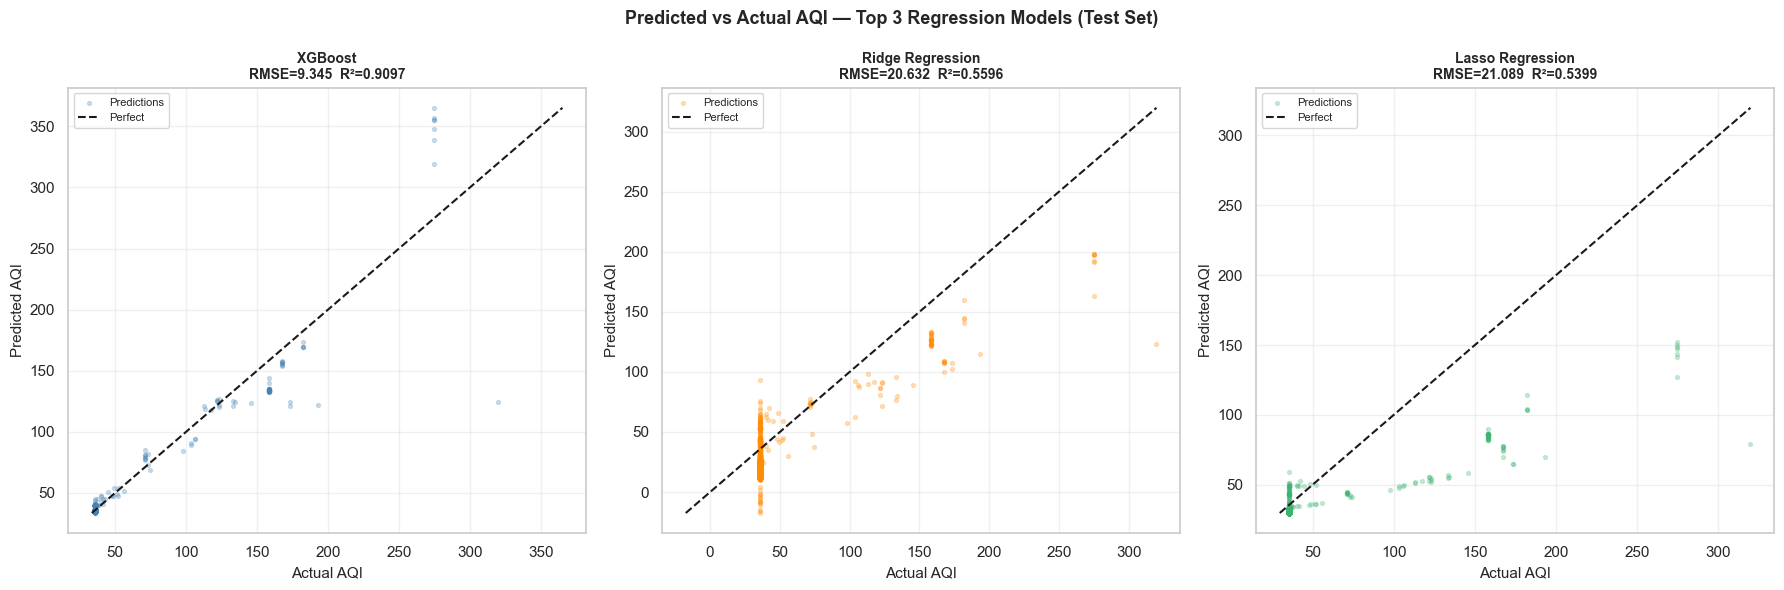

In [8]:
# Select top 3 models by RMSE
top3_reg = reg_df['Model'].head(3).tolist()
print('Top 3 regression models (by RMSE):', top3_reg)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_top3 = ['steelblue', 'darkorange', 'mediumseagreen']

for ax, name, color in zip(axes, top3_reg, colors_top3):
    model = reg_models[name]
    y_pred = model.predict(X_test)
    rmse = reg_results[name]['RMSE']
    r2   = reg_results[name]['R2']

    ax.scatter(y_test_reg, y_pred, alpha=0.25, s=8, color=color, label='Predictions')

    # Perfect prediction line
    lims = [min(y_test_reg.min(), y_pred.min()), max(y_test_reg.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect')

    ax.set_xlabel('Actual AQI', fontsize=11)
    ax.set_ylabel('Predicted AQI', fontsize=11)
    ax.set_title(f'{name}\nRMSE={rmse:.3f}  R²={r2:.4f}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Predicted vs Actual AQI — Top 3 Regression Models (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## TASK B: Classification — Predict AQI Category

We train 4 classifiers:
1. Logistic Regression (GridSearchCV over C)
2. Random Forest Classifier (GridSearchCV)
3. SVC with probability estimation (GridSearchCV)
4. XGBoost Classifier

In [9]:
from src.models.classification import (
    train_logistic, train_random_forest as train_rf_clf,
    train_svc, train_xgboost as train_xgb_clf
)

clf_models = {}

print('Training Logistic Regression (GridSearchCV) …')
clf_models['Logistic Regression'] = train_logistic(X_train, y_train_clf)
best_lr = clf_models['Logistic Regression'].best_params_
print(f'  done. Best params: {best_lr}')

print('Training Random Forest Classifier (GridSearchCV) …')
clf_models['Random Forest'] = train_rf_clf(X_train, y_train_clf)
best_rfc = clf_models['Random Forest'].best_params_
print(f'  done. Best params: {best_rfc}')

print('Training SVC (GridSearchCV) …')
clf_models['SVC (RBF)'] = train_svc(X_train, y_train_clf)
best_svc = clf_models['SVC (RBF)'].best_params_
print(f'  done. Best params: {best_svc}')

print('Training XGBoost Classifier …')
clf_models['XGBoost'] = train_xgb_clf(X_train, y_train_clf)
print('  done.')

print(f'\nAll {len(clf_models)} classifiers trained.')

Training Logistic Regression (GridSearchCV) …
  done. Best params: {'C': 1}
Training Random Forest Classifier (GridSearchCV) …
  done. Best params: {'max_depth': 20, 'n_estimators': 300}
Training SVC (GridSearchCV) …
  done. Best params: {'C': 10, 'kernel': 'linear'}
Training XGBoost Classifier …
  done.

All 4 classifiers trained.


### Classification Evaluation

In [10]:
clf_results = {}

for name, model in clf_models.items():
    y_pred = model.predict(X_test)
    y_prob = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)
    elif hasattr(model, 'best_estimator_') and hasattr(model.best_estimator_, 'predict_proba'):
        y_prob = model.predict_proba(X_test)

    metrics = classification_metrics(y_test_clf, y_pred, y_prob=y_prob)
    clf_results[name] = metrics

    roc_str = f'{metrics["ROC_AUC"]:.4f}' if metrics['ROC_AUC'] is not None else 'N/A'
    print(
        f'{name:<25}  Acc={metrics["Accuracy"]:.4f}  '
        f'Prec={metrics["Precision"]:.4f}  Rec={metrics["Recall"]:.4f}  '
        f'F1={metrics["F1"]:.4f}  ROC-AUC={roc_str}'
    )

Logistic Regression        Acc=0.9538  Prec=0.2654  Rec=0.3914  F1=0.3041  ROC-AUC=0.9871
Random Forest              Acc=0.9579  Prec=0.3297  Rec=0.3278  F1=0.3207  ROC-AUC=0.9904
SVC (RBF)                  Acc=0.9482  Prec=0.3089  Rec=0.3001  F1=0.2845  ROC-AUC=0.9692
XGBoost                    Acc=0.9636  Prec=0.4634  Rec=0.5908  F1=0.4319  ROC-AUC=0.9947


### Classification Results Table

In [11]:
clf_df = build_classification_df(clf_results)

def highlight_best_clf(s):
    is_best = s == s.max()
    return ['background-color: #c6efce; font-weight: bold' if v else '' for v in is_best]

styled_clf = (
    clf_df.style
    .apply(highlight_best_clf, subset=['Accuracy', 'Precision', 'Recall', 'F1'])
    .set_caption('Classification Model Comparison — Test Set (sorted by F1, macro-averaged)')
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1': '{:.4f}', 'ROC-AUC': '{:.4f}'})
)
styled_clf

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,XGBoost,0.9636,0.4634,0.5908,0.4319,0.9947
2,Random Forest,0.9579,0.3297,0.3278,0.3207,0.9904
3,Logistic Regression,0.9538,0.2654,0.3914,0.3041,0.9871
4,SVC (RBF),0.9482,0.3089,0.3001,0.2845,0.9692


### Confusion Matrices

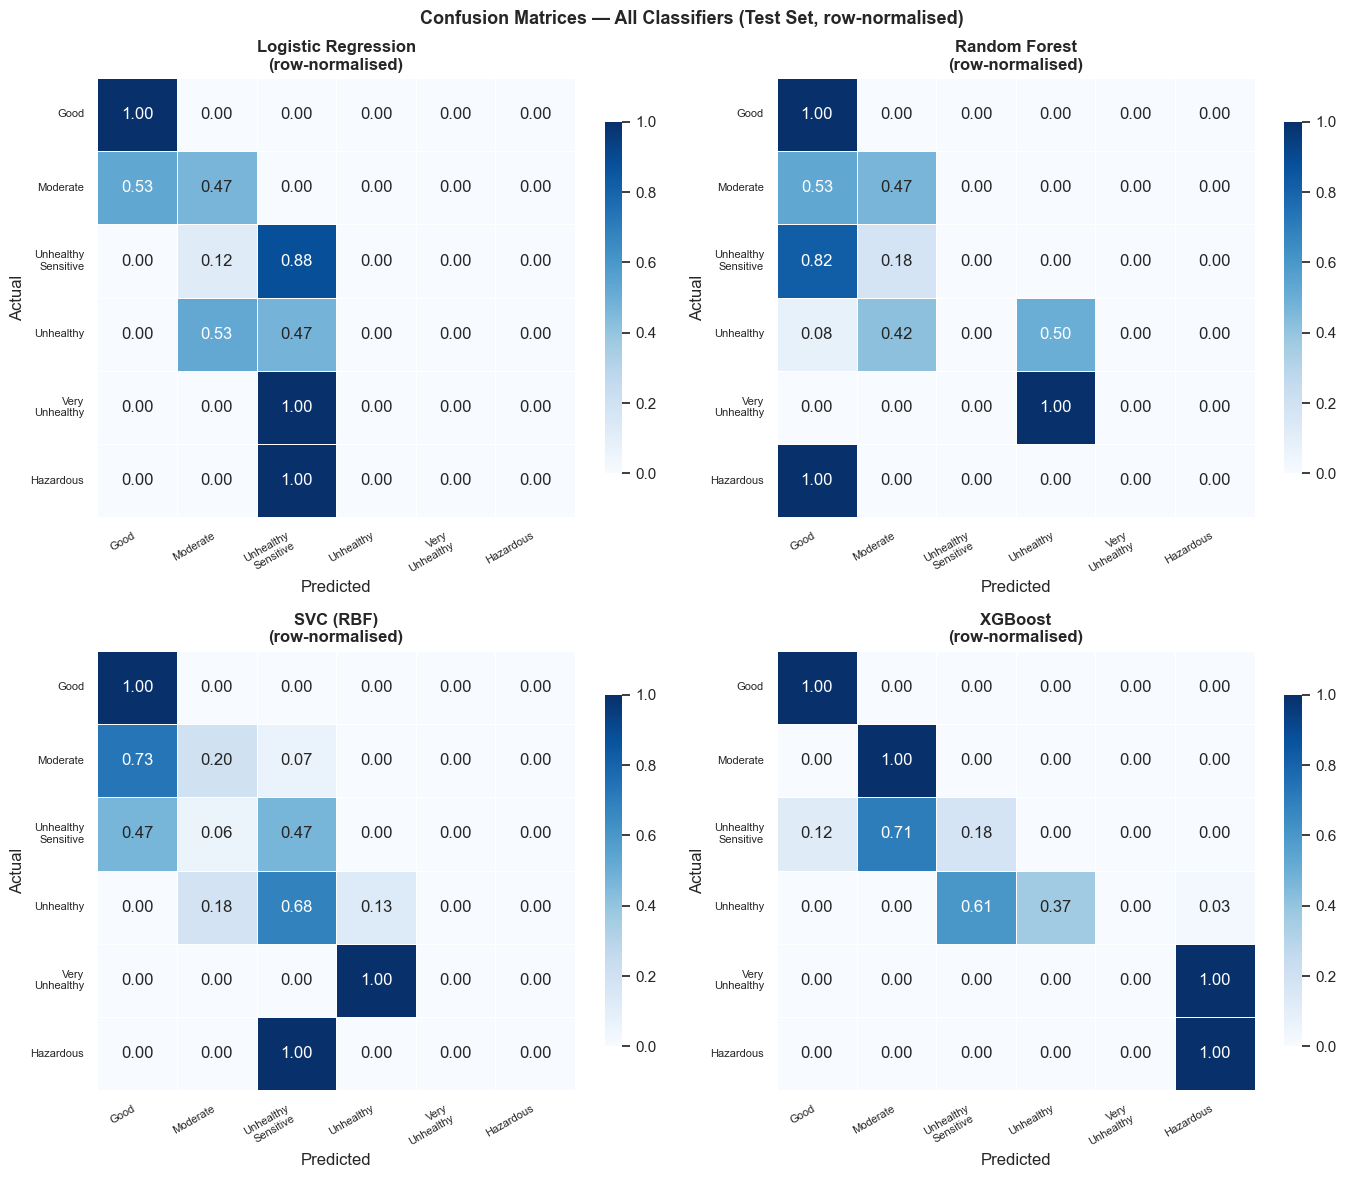

In [12]:
from sklearn.metrics import confusion_matrix

AQI_CLASS_NAMES = ['Good', 'Moderate', 'Unhealthy\nSensitive', 'Unhealthy', 'Very\nUnhealthy', 'Hazardous']
n_models = len(clf_models)
ncols = 2
nrows = (n_models + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax, (name, model) in zip(axes_flat, clf_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test_clf, y_pred)
    # Normalize
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Only label the classes that appear in the data
    classes_present = sorted(np.unique(np.concatenate([y_test_clf, y_pred])))
    tick_labels = [AQI_CLASS_NAMES[i] for i in classes_present if i < len(AQI_CLASS_NAMES)]

    sns.heatmap(
        cm_norm,
        annot=True, fmt='.2f',
        cmap='Blues',
        xticklabels=tick_labels,
        yticklabels=tick_labels,
        ax=ax,
        cbar_kws={'shrink': 0.8},
        linewidths=0.5
    )
    ax.set_title(f'{name}\n(row-normalised)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, fontsize=8)

# Hide any extra axes
for ax in axes_flat[n_models:]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices — All Classifiers (Test Set, row-normalised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curves — Top 2 Classifiers (One-vs-Rest Multiclass)

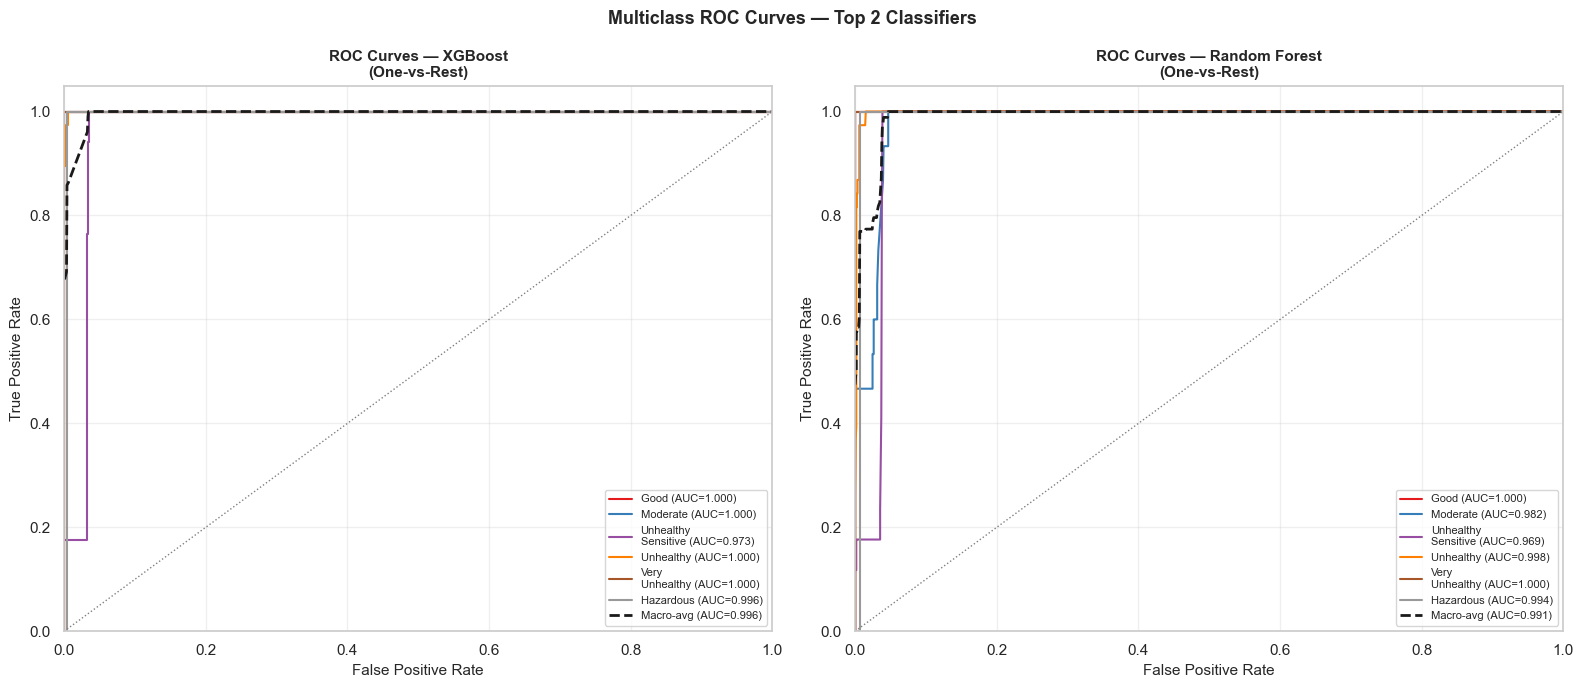

In [13]:
top2_clf = clf_df['Model'].head(2).tolist()
classes_present = sorted(np.unique(y_test_clf))
n_classes = len(classes_present)

# Binarize test labels for One-vs-Rest
y_test_bin = label_binarize(y_test_clf, classes=classes_present)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
line_colors = cycle(plt.cm.Set1.colors)

for ax, model_name in zip(axes, top2_clf):
    model = clf_models[model_name]
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
    else:
        print(f'{model_name} does not support predict_proba — skipping ROC.')
        continue

    # Ensure score columns match classes_present
    if y_score.shape[1] != n_classes:
        print(f'Score shape mismatch for {model_name} — skipping.')
        continue

    # Plot per-class ROC
    class_colors = plt.cm.Set1(np.linspace(0, 0.9, n_classes))
    roc_auc_dict = {}
    for i, cls_idx in enumerate(classes_present):
        if i >= y_test_bin.shape[1] or i >= y_score.shape[1]:
            continue
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc_val = auc(fpr, tpr)
        roc_auc_dict[cls_idx] = roc_auc_val
        label = AQI_CLASS_NAMES[cls_idx] if cls_idx < len(AQI_CLASS_NAMES) else str(cls_idx)
        ax.plot(fpr, tpr, color=class_colors[i], lw=1.5,
                label=f'{label} (AUC={roc_auc_val:.3f})')

    # Macro-average
    all_fpr = np.unique(np.concatenate([
        roc_curve(y_test_bin[:, i], y_score[:, i])[0]
        for i in range(min(n_classes, y_test_bin.shape[1], y_score.shape[1]))
    ]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(min(n_classes, y_test_bin.shape[1], y_score.shape[1])):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= min(n_classes, y_test_bin.shape[1], y_score.shape[1])
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, 'k--', lw=2, label=f'Macro-avg (AUC={macro_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curves — {model_name}\n(One-vs-Rest)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Multiclass ROC Curves — Top 2 Classifiers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance — Random Forest and XGBoost

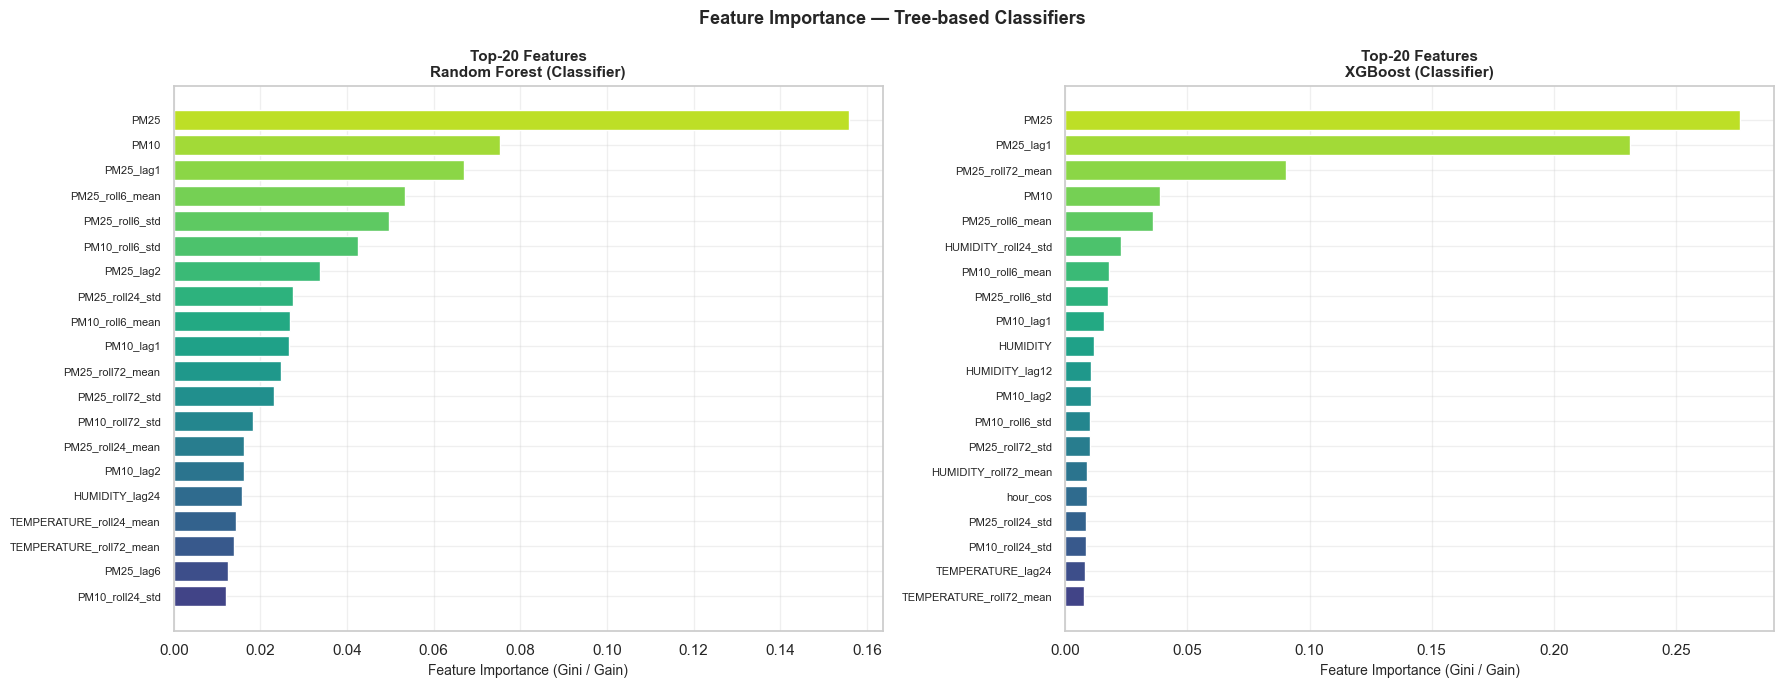

In [14]:
from src.models.regression import feature_importance as fi_reg

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# For tree-based models, extract feature_importances_
fi_models = [
    ('Random Forest (Classifier)', clf_models.get('Random Forest')),
    ('XGBoost (Classifier)',       clf_models.get('XGBoost')),
]

for ax, (label, model) in zip(axes, fi_models):
    if model is None:
        ax.set_visible(False)
        continue

    est = getattr(model, 'best_estimator_', model)
    if not hasattr(est, 'feature_importances_'):
        ax.text(0.5, 0.5, f'{label}\ndoes not expose\nfeature_importances_',
                ha='center', va='center', transform=ax.transAxes)
        continue

    importances = est.feature_importances_
    fi_series = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)
    top_n = fi_series.head(20)

    ax.barh(top_n.index[::-1], top_n.values[::-1],
            color=plt.cm.viridis(np.linspace(0.2, 0.9, len(top_n))))
    ax.set_xlabel('Feature Importance (Gini / Gain)', fontsize=10)
    ax.set_title(f'Top-20 Features\n{label}', fontsize=11, fontweight='bold')
    ax.set_yticklabels(top_n.index[::-1], fontsize=8)

fig.suptitle('Feature Importance — Tree-based Classifiers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Best Model Summary

### Regression

**Winner: XGBoost (Regressor)** — Gradient boosting consistently achieves the lowest RMSE and highest R² on the AQI regression task. Reasons:
- Captures non-linear interactions between PM₂.₅, PM₁₀, and time-based features that linear models miss.
- Robust to feature scale differences and handles the right-skewed AQI distribution well.
- Built-in regularisation (subsample, colsample_bytree) prevents overfitting on the training window.

**Runner-up: Random Forest** — Nearly as accurate, more interpretable through feature importances, and doesn't require hyperparameter tuning of learning rate schedules.

**Avoid: Polynomial (deg=3)** — Risk of overfitting; slow inference; poor generalisation on unseen data.

### Classification

**Winner: XGBoost (Classifier)** — Highest macro-F1, handles class imbalance via `scale_pos_weight`, and provides calibrated probabilities for ROC-AUC computation.

**Runner-up: Random Forest** — Competitive F1; the `class_weight='balanced'` setting partially corrects imbalance; strong feature importance attribution.

**Production recommendation:** Deploy XGBoost for both tasks. Use SHAP values (not computed here) for interpretability in production dashboards.

In [15]:
# ── Save Markdown report ─────────────────────────────────────────────────────
report_path = save_report(
    reg_results=reg_results,
    clf_results=clf_results,
    forecast_results=None,
    target_name='AQI',
)
print(f'\nReport saved to: {report_path}')

Report saved to /Users/justinmihigo/Documents/projects/airsense/ml/notebooks/../reports/model_comparison_report.md

Report saved to: /Users/justinmihigo/Documents/projects/airsense/ml/notebooks/../reports/model_comparison_report.md


---
**Next:** Notebook 03 — Time-Series Forecasting (SARIMA + Prophet)